# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div>
    
|    Group   |           1          |
|------------|----------------------|
| Junhan Chong  |        6153283       |
| Jack Bergmann  |        6200850       |
| Madhav Tiwari  |        6141870       |
| Ben Chen  |        6543405       |

#### Imports

In [124]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [125]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        # choose an action from the list of valid actions randomly, with uniform distribution
        chosen_action = np.random.choice(valid_as)
        # take the chosen action
        return chosen_action

        


    def e_greedy(self, agent: Agent, maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        s = agent.get_state(maze)

        # find the corresponding q values for the possible actions
        q_vals = [self.q_table.get_q(s, a) for a in valid_as]

        # find the actions with largest q value(s)
        max_q = np.max(q_vals)
        max_q_actions = [a for a, q in zip(valid_as, q_vals) if q == max_q]

        chosen_action = None
        # with probability of 1 - eps, select randomly from actions with the largest q values
        if (np.random.uniform() > eps):
            chosen_action = np.random.choice(max_q_actions)
        # with probability of eps, select randomly from the list of possible actions
        else:
            not_max = [a for a in valid_as if a not in max_q_actions]
            if len(not_max) == 0:
                chosen_action = np.random.choice(valid_as)
            else:
                chosen_action = np.random.choice(not_max)
        # take the chosen action
        return chosen_action



    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration and as the temperature declines over time,
        exploitation is favoured. 
        """
        # find all possible actions for the particular state that the agent is in
        valid_as = agent.get_valid_actions(maze)
        s = agent.get_state(maze)

        # find the corresponding q values for the possible actions
        q_vals = [self.q_table.get_q(s, a) for a in valid_as]
        # subtract max q val for numerical stability
        q_vals = np.array(q_vals)
        q_vals = q_vals - np.max(q_vals)

        # guard against zero-division
        if temperature <= 0:
            # apply greedy if temperature is zero
            max_q = np.max(q_vals)
            max_q_actions = [a for a, q in zip(valid_as, q_vals) if q == max_q]
            chosen_action = np.random.choice(max_q_actions)
            return chosen_action

        # calculate exp(Q(s,a) / T) for all possible actions
        boltzmann_probs = np.exp(q_vals / temperature)

        # find the sum and divide each term by the sum
        boltzmann_probs /= np.sum(boltzmann_probs)

        
        # choose an action with the boltzmann probabilities as the weights
        chosen_action = np.random.choice(valid_as, p=boltzmann_probs)

        # take the chosen action
        return chosen_action

<div>

**Explain what you did, including the initial selection of the hyper-parameter values. How do you deal with exploration/exploitation tradeoff?**

All three strategies start with finding the valid actions that the agent can take at its current state. This is because the probability of choosing an invalid action should be zero in all given strategies.

For random exploration, I chose an action randomly based on an uniform distribution between the available actions. There are no hyper-parameters for this strategy because all decisions are made with a random uniform probability between actions. Therefore, this exploration strategy would be used initially to maximise exploration while neglecting exploitation.

For $\epsilon$-greedy exploration, I found the corresponding Q values for the possible actions to use for the greedy property of this strategy. With the Q values, we can simply choose the action with the highest associated Q value by definition. However, this approach would only use exploitation without the use of exploration since at any given point, the agent deterministically chooses what action to take. Therefore, we introduce a hyperparameter: $\epsilon$, to introduce exploration. Increasing $\epsilon$ increases exploration by increasing the probability of a random action being chosen, naturally decreasing exploitation as well. Therefore, we must find a suitable value of $\epsilon$ to achieve a good balance of exploitation and exploration in order to avoid convergence at a local optima, while keeping the learning relatively fast and efficient.

For Boltzmann exploration, we assign weights to the different actions to be used as the probability distribution. After finding the corresponding Q values for all possible actions, we use the softmax formula to assign probabilities for the actions. However, just by using the softmax function to assign weights for probability means we cannot tune the strategy to encourage or discourage more exploitation. Therefore, we introduce a hyperparameter $\tau$ (true Boltzmann exploration) which influences the probability of all possible actions. As we increase $\tau$, the probabilities decrease exponentially to its magnitude (because of the exponentiation). Hence, decreasing $\tau$ leads to more exploitation (as the higher Q value actions would be assigned a larger the probability relative to the lower Q value actions) while increasing it will even out the probability distribution towards uniform distribution; As $\tau$ approaches the limit of 0, the approach becomes greedier and greedier, while $T$ approaching infinity would make the strategy choose actions from a uniform distribution.

In practice, we should choose hyperparameters that encourage exploration (large $\epsilon$, large $\tau$) initially, so the agent can learn about the environment and map out a sensible Q table. As the agent explores, we can decrease the hyperparameters to favour more and more exploitation.

Hence, we can use Boltzmann exploration with a large value of $\tau$ initially to encourage exploration, then gradually 'decay' the temperature over each episode until it reaches a threshold to increase exploitation gradually. Since we have four actions per state, with a reward of 10 at the terminal state (initially), our Q values will not be larger than 10. Therefore, we can choose a relatively small value for the temperature, such as $\tau = 1$. Then we can use a fixed percentage value such as 0.99 to slowly decay the temperature over episodes. These hyper-parameters can be optimised during training (with the validation set) to maximise efficiency while minimising the risk of early convergence at a local optima.

#### Question 2

In [126]:
# Create a Maze instance.
easy_maze = Maze("./../data/easy_maze.txt")
easy_maze.set_reward(x = 9, y = 9, reward = 10)
easy_maze.set_terminal(x = 9, y = 9)

def main_no_learn(maze, n_episodes = 300, alpha = 0.1, discount = 0.9, decay = 0.99, temperature = 1):
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    # learner = QLearning(q_table, params)

    
    # repeat exploration #n_episodes amount of time
    for episode in tqdm(range(n_episodes)):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        # explore until terminal state
        while (agent.get_state(maze).done == False):
            # one exploration step
            current_state = agent.get_state(maze)
            chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            next_state, r, done = agent.step(chosen_action, maze)

            ## updating Q table is the learner's job ##

            # variables for Q table update calculations
            # q_old = q_table.get_q(current_state, chosen_action)
            # q_max_new = np.max([q_table.get_q(next_state, a) for a in agent.get_valid_actions(maze)])

            # update Q table
            # q_table.set_q(current_state, chosen_action, 
                        # q_old + alpha * (r + discount * q_max_new - q_old))
            
            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
        
        # decay the temperature every episode
        temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)


<div>

**Explain the cycle in your report.**

The cycle consists of three steps until the agent reaches a terminal state:
1. **Take action step:** We decide on the action for the agent to take. We used the Boltzmann strategy, with an initial temperature of 1.0. We then take the chosen action, getting the new state and reward for the action (at the particular state) as a return value. <br>
*\<This step is necessary for the agent to explore the environment\>*
2. **Update Q table:** We take the Q values of the initial state and action that we've chosen, as well as the Q values for max state-action value for the next state. Using these, we calculate the new Q value for the initial state-action pair. <br>
*\<This step is necessary to learn the environment. Q table is what is used to exploit efficient paths\>*
3. **Update states and reward metrics:** We then update the current state variable to the new position of the agent, as well as incrementing the rewards and step count to use as a performance metric. <br>
*\<This step is necessary to evaluate progress and allow for a cycle\>*

This cycle can be repeated until the agent reaches the terminal state, at which a new episode will start. These three steps are sufficient for a complete trial/episode (agent exploring from the start to terminal state) as it can explore the environment and learn from it (Q table). Repeating this cycle over the episodes will lead to a convergence in the Q value according to the **Stochastic Approximation Theory**. Then we can improve the policy based on the values from the Q table.

#### Question 3

In [127]:
def main_early_stop_no_learn(maze, n_episodes = 300, decay = 0.99, temperature = 1, early_stop = 30000):
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)

    # Create a QTable
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    
    # Create an ExplorationStrategy
    exploration_strategy = ExplorationStrategy(q_table)

    # global step tracker
    total_steps = 0
    episodes = 0

    # repeat exploration #n_episodes amount of time
    for episode in range(n_episodes):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        # explore until terminal state
        while (agent.get_state(maze).done == False):
            if (total_steps >= early_stop):
                break
            ## STEP 1: TAKE STEP ##
            current_state = agent.get_state(maze)
            chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            next_state, r, done = agent.step(chosen_action, maze)

            ## STEP 2: UPDATE Q TABLE / LEARN ##
            
            ## STEP 3: RECORD STATE AND REWARDS ##
            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
            total_steps += 1
        
        # decay the temperature every episode
        temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)

        episodes += 1
        print(f"{ steps } steps at episode { episodes }")

        if (total_steps >= early_stop):
            print(f"{ total_steps } steps reached. Terminating current episode.")
            print(f"Stopped at episode number: { episodes }")
            break
        
    return episode_lengths

In [128]:
main_early_stop_no_learn(easy_maze)

382 steps at episode 1
980 steps at episode 2
292 steps at episode 3
284 steps at episode 4
2944 steps at episode 5
396 steps at episode 6
398 steps at episode 7
168 steps at episode 8
296 steps at episode 9
7558 steps at episode 10
514 steps at episode 11
1886 steps at episode 12
154 steps at episode 13
2188 steps at episode 14
5942 steps at episode 15
3738 steps at episode 16
862 steps at episode 17
520 steps at episode 18
348 steps at episode 19
150 steps at episode 20
30000 steps reached. Terminating current episode.
Stopped at episode number: 20


[382,
 980,
 292,
 284,
 2944,
 396,
 398,
 168,
 296,
 7558,
 514,
 1886,
 154,
 2188,
 5942,
 3738,
 862,
 520,
 348,
 150]

<div>

We introduced a global step counter that gets incremented at every step. Since there are two loops, with the outer loop iterating over the episodes and the inner loop iterating over the cycles, we include a break statement in both blocks to ensure that the cycle and the episode are both terminated once reaching 30,000 steps. To verify, we included two simple print statements printing some meta data about the runs (number of episodes, total steps).

We can also note from the steps per episode, that there is a very large variance between episodes, ranging from 100 to over 10,000 steps per episode. There also doesn't seem to be a clear decrease in the number of steps per episode. This is expected as we have not implemented the learning function.

#### Question 4

In [129]:
toy_maze = Maze("./../data/toy_maze.txt")
toy_maze.set_reward(x = 9, y = 9, reward = 10)
toy_maze.set_terminal(x = 9, y = 9)

def run_multiple_no_learn(maze, n_runs = 10, early_stop = 30000):
    all_runs = []

    for i in range(n_runs):
        episode_lengths = main_early_stop_no_learn(
            maze, early_stop
        )
        all_runs.append(episode_lengths)

    return all_runs


def plot_average_episode_lengths(all_runs, difficulty, learning_type = "None"):
    # find max number of episodes across runs
    max_len = max(len(run) for run in all_runs)

    # pad runs with NaN so they all have equal length
    padded_runs = []
    for run in all_runs:
        padded = run + [np.nan] * (max_len - len(run))
        padded_runs.append(padded)

    padded_runs = np.array(padded_runs)

    # compute mean ignoring NaNs
    avg_lengths = np.nanmean(padded_runs, axis=0)
    stds = np.nanstd(padded_runs, axis=0)
    epochs = np.arange(len(avg_lengths)) # for axis labelling with no .5s

    # plot
    plt.figure()
    plt.plot(epochs, avg_lengths, label="Average")
    plt.fill_between(
        epochs,
        np.maximum(avg_lengths - stds, 0),
        avg_lengths + stds,
        alpha=0.3
    )
    plt.xlabel("Episode")
    plt.ylabel("Average Steps per Episode")
    if learning_type == "None":
        plt.title(f"Average episode length over runs in { difficulty } maze")
    else:
        plt.title(f"Average episode length over runs in { difficulty } maze using {learning_type}")
    plt.show()




902 steps at episode 1
684 steps at episode 2
548 steps at episode 3
208 steps at episode 4
1562 steps at episode 5
410 steps at episode 6
638 steps at episode 7
216 steps at episode 8
5310 steps at episode 9
620 steps at episode 10
3642 steps at episode 11
1072 steps at episode 12
804 steps at episode 13
280 steps at episode 14
950 steps at episode 15
1686 steps at episode 16
640 steps at episode 17
1458 steps at episode 18
1804 steps at episode 19
208 steps at episode 20
1362 steps at episode 21
240 steps at episode 22
1130 steps at episode 23
1842 steps at episode 24
1784 steps at episode 25
30000 steps reached. Terminating current episode.
Stopped at episode number: 25
1194 steps at episode 1
732 steps at episode 2
940 steps at episode 3
390 steps at episode 4
3266 steps at episode 5
1390 steps at episode 6
1644 steps at episode 7
1460 steps at episode 8
412 steps at episode 9
1148 steps at episode 10
1208 steps at episode 11
1074 steps at episode 12
600 steps at episode 13
746 ste

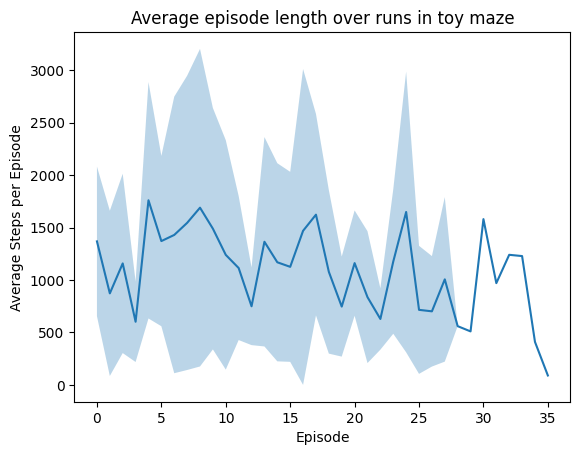

298 steps at episode 1
1884 steps at episode 2
2854 steps at episode 3
1956 steps at episode 4
5420 steps at episode 5
762 steps at episode 6
200 steps at episode 7
606 steps at episode 8
234 steps at episode 9
868 steps at episode 10
5280 steps at episode 11
520 steps at episode 12
1410 steps at episode 13
890 steps at episode 14
932 steps at episode 15
286 steps at episode 16
5600 steps at episode 17
30000 steps reached. Terminating current episode.
Stopped at episode number: 17
1450 steps at episode 1
1924 steps at episode 2
3566 steps at episode 3
688 steps at episode 4
1210 steps at episode 5
686 steps at episode 6
220 steps at episode 7
16202 steps at episode 8
2358 steps at episode 9
148 steps at episode 10
1548 steps at episode 11
30000 steps reached. Terminating current episode.
Stopped at episode number: 11
208 steps at episode 1
3084 steps at episode 2
1372 steps at episode 3
1986 steps at episode 4
1020 steps at episode 5
730 steps at episode 6
1626 steps at episode 7
504 s

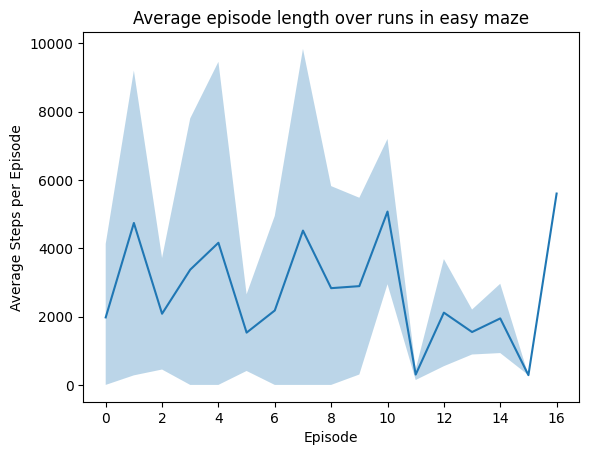

In [130]:
plot_average_episode_lengths(run_multiple_no_learn(toy_maze, early_stop=100000), "toy")
plot_average_episode_lengths(run_multiple_no_learn(easy_maze, early_stop=300000), "easy")

<div>

The plot shows that there is no clear downwards trend for each consecutive episodes in the average over all runs. This indicates that the agent does not take more efficient paths over episode progression due to the lack of learning (updating of the Q table).
Towards the ends of the runs, the average is calculated from fewer values than earlier because some runs might terminate earlier. Therefore, there may be an increased volatility that makes it look like the plot is showing certain trends.

#### Question 5

In [131]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        # variables for Q table update calculations
        q_old = self.q_table.get_q(state, action)
        q_max_new = np.max([self.q_table.get_q(next_state, a) for a in possible_actions])

        # update Q table
        self.q_table.set_q(state, action, 
                    q_old + self.params["lr"] * (reward + self.params["gamma"] * q_max_new - q_old))

In [132]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        # variables for Q table update calculations
        q_old = self.q_table.get_q(state, action)
        q_new = self.q_table.get_q(next_state, next_action)

        # update Q table
        self.q_table.set_q(state, action, 
                    q_old + self.params["lr"] * (reward + self.params["gamma"] * q_new - q_old))

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

#### Question 6

In [133]:
def main_early_stop(maze, n_episodes = 300, params = {"lr": 0.7, "gamma": 0.9}, decay = 0.99, eps = 0.0, temperature = 1, early_stop = 30000, q_learning=True, strategy="boltzmann"): # 
    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []

    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)

    # Create a QTable
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    
    # Create an ExplorationStrategy
    exploration_strategy = ExplorationStrategy(q_table)

    # Create a learner
    if (q_learning):
        learner = QLearning(q_table, params)
    else:
        learner = SARSA(q_table, params)

    # global step tracker
    total_steps = 0
    episodes = 0

    # repeat exploration #n_episodes amount of time
    for episode in range(n_episodes):
        # put agent at the start
        agent.reset()

        #counter to check progress
        steps = 0
        total_r = 0

        # explore until terminal state
        while (agent.get_state(maze).done == False):
            if (total_steps >= early_stop):
                break
            # one exploration step
            current_state = agent.get_state(maze)
            if strategy == "random":
                chosen_action = exploration_strategy.random(agent, maze)
            elif strategy == "e_greedy":
                chosen_action = exploration_strategy.e_greedy(agent, maze, eps)
            elif strategy == "boltzmann":
                chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            else:
                chosen_action = exploration_strategy.boltzmann(agent, maze, temperature)
            next_state, r, done = agent.step(chosen_action, maze)
                
            # variables for Q table update calculations
            if (q_learning):
                learner.learn(agent.get_valid_actions(maze), current_state, chosen_action, next_state, r, done)
            else:
                next_action = exploration_strategy.boltzmann(agent, maze, temperature)
                learner.learn(current_state, chosen_action, next_state, next_action, r, done)

            # re-assign/increment control variables
            current_state = next_state
            total_r += r
            steps += 1
            total_steps += 1
        
        # decay the temperature every episode
        temperature *= decay

        # append progress variables to progress tracker
        episode_rewards.append(total_r)
        episode_lengths.append(steps)

        episodes += 1
        print(f"{ steps } steps at episode { episodes }")

        if (total_steps >= early_stop):
            print(f"{ total_steps } steps reached. Terminating current episode.")
            print(f"Stopped at episode number: { episodes }")
            break
        
    return episode_lengths

def run_multiple_q(maze, n_runs = 10, params = {"lr": 0.7, "gamma": 0.9}, decay = 0.99, eps = 0.1, temperature = 1, early_stop = 30000, q_learning=True, strategy="boltzmann"):
    all_runs = []

    for i in range(n_runs):
        episode_lengths = main_early_stop(
            maze, early_stop = early_stop, q_learning = q_learning, strategy = strategy, eps = eps, temperature = temperature, decay = decay, params = params
        )
        all_runs.append(episode_lengths)

    return all_runs


3040 steps at episode 1
272 steps at episode 2
1744 steps at episode 3
1206 steps at episode 4
552 steps at episode 5
216 steps at episode 6
230 steps at episode 7
4414 steps at episode 8
6386 steps at episode 9
132 steps at episode 10
192 steps at episode 11
1426 steps at episode 12
138 steps at episode 13
2990 steps at episode 14
128 steps at episode 15
718 steps at episode 16
778 steps at episode 17
40 steps at episode 18
3864 steps at episode 19
136 steps at episode 20
632 steps at episode 21
142 steps at episode 22
218 steps at episode 23
36 steps at episode 24
38 steps at episode 25
120 steps at episode 26
154 steps at episode 27
50 steps at episode 28
408 steps at episode 29
48 steps at episode 30
22 steps at episode 31
96 steps at episode 32
66 steps at episode 33
136 steps at episode 34
98 steps at episode 35
66 steps at episode 36
60 steps at episode 37
42 steps at episode 38
84 steps at episode 39
34 steps at episode 40
38 steps at episode 41
136 steps at episode 42
56 steps

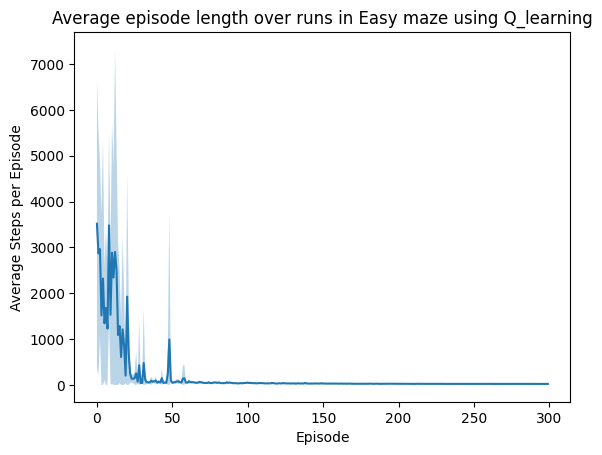

112 steps at episode 1
344 steps at episode 2
1044 steps at episode 3
1490 steps at episode 4
814 steps at episode 5
3812 steps at episode 6
268 steps at episode 7
352 steps at episode 8
2264 steps at episode 9
98 steps at episode 10
2698 steps at episode 11
316 steps at episode 12
1266 steps at episode 13
904 steps at episode 14
252 steps at episode 15
192 steps at episode 16
176 steps at episode 17
70 steps at episode 18
622 steps at episode 19
46 steps at episode 20
42 steps at episode 21
88 steps at episode 22
50 steps at episode 23
28 steps at episode 24
60 steps at episode 25
164 steps at episode 26
176 steps at episode 27
2708 steps at episode 28
46 steps at episode 29
1516 steps at episode 30
64 steps at episode 31
108 steps at episode 32
34 steps at episode 33
54 steps at episode 34
314 steps at episode 35
34 steps at episode 36
70 steps at episode 37
58 steps at episode 38
32 steps at episode 39
32 steps at episode 40
82 steps at episode 41
26 steps at episode 42
592 steps at

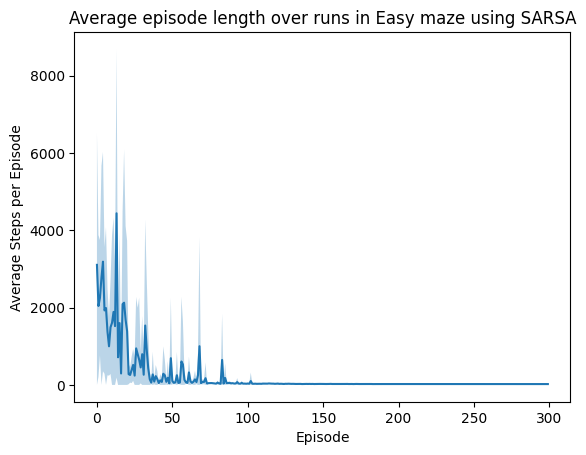

In [134]:
plot_average_episode_lengths(run_multiple_q(easy_maze, early_stop=500000), "Easy", learning_type="Q_learning")
plot_average_episode_lengths(run_multiple_q(easy_maze, early_stop=500000, q_learning = False), "Easy", learning_type="SARSA")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 7

<div style="background-color:#f1be3e">

_Write your answer here._

### 2.2 Optimization
#### Question 8

850 steps at episode 1
672 steps at episode 2
1342 steps at episode 3
162 steps at episode 4
460 steps at episode 5
1290 steps at episode 6
178 steps at episode 7
2168 steps at episode 8
286 steps at episode 9
430 steps at episode 10
116 steps at episode 11
316 steps at episode 12
406 steps at episode 13
572 steps at episode 14
454 steps at episode 15
64 steps at episode 16
166 steps at episode 17
102 steps at episode 18
376 steps at episode 19
110 steps at episode 20
116 steps at episode 21
28 steps at episode 22
290 steps at episode 23
310 steps at episode 24
264 steps at episode 25
74 steps at episode 26
28 steps at episode 27
40 steps at episode 28
34 steps at episode 29
134 steps at episode 30
52 steps at episode 31
26 steps at episode 32
24 steps at episode 33
24 steps at episode 34
24 steps at episode 35
24 steps at episode 36
24 steps at episode 37
24 steps at episode 38
24 steps at episode 39
24 steps at episode 40
24 steps at episode 41
24 steps at episode 42
24 steps at epis

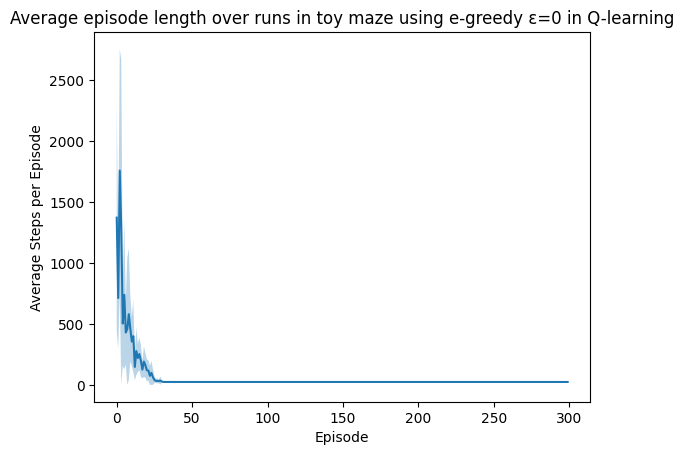

4738 steps at episode 1
722 steps at episode 2
552 steps at episode 3
3288 steps at episode 4
540 steps at episode 5
1406 steps at episode 6
346 steps at episode 7
260 steps at episode 8
642 steps at episode 9
444 steps at episode 10
72 steps at episode 11
90 steps at episode 12
284 steps at episode 13
138 steps at episode 14
128 steps at episode 15
208 steps at episode 16
208 steps at episode 17
142 steps at episode 18
292 steps at episode 19
116 steps at episode 20
204 steps at episode 21
28 steps at episode 22
120 steps at episode 23
114 steps at episode 24
100 steps at episode 25
28 steps at episode 26
34 steps at episode 27
48 steps at episode 28
24 steps at episode 29
34 steps at episode 30
30 steps at episode 31
26 steps at episode 32
28 steps at episode 33
28 steps at episode 34
28 steps at episode 35
30 steps at episode 36
30 steps at episode 37
24 steps at episode 38
32 steps at episode 39
26 steps at episode 40
32 steps at episode 41
26 steps at episode 42
26 steps at episod

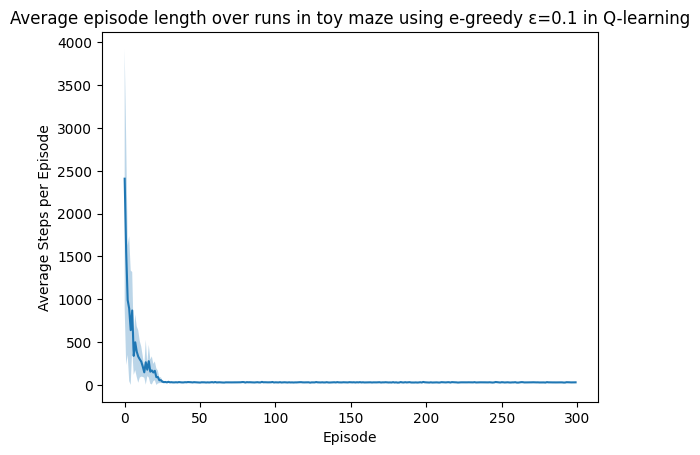

2344 steps at episode 1
494 steps at episode 2
2004 steps at episode 3
168 steps at episode 4
184 steps at episode 5
556 steps at episode 6
306 steps at episode 7
222 steps at episode 8
264 steps at episode 9
82 steps at episode 10
172 steps at episode 11
102 steps at episode 12
260 steps at episode 13
64 steps at episode 14
88 steps at episode 15
90 steps at episode 16
36 steps at episode 17
84 steps at episode 18
52 steps at episode 19
56 steps at episode 20
34 steps at episode 21
38 steps at episode 22
108 steps at episode 23
28 steps at episode 24
44 steps at episode 25
70 steps at episode 26
52 steps at episode 27
44 steps at episode 28
96 steps at episode 29
56 steps at episode 30
44 steps at episode 31
48 steps at episode 32
58 steps at episode 33
62 steps at episode 34
42 steps at episode 35
62 steps at episode 36
44 steps at episode 37
40 steps at episode 38
50 steps at episode 39
40 steps at episode 40
82 steps at episode 41
72 steps at episode 42
56 steps at episode 43
62 st

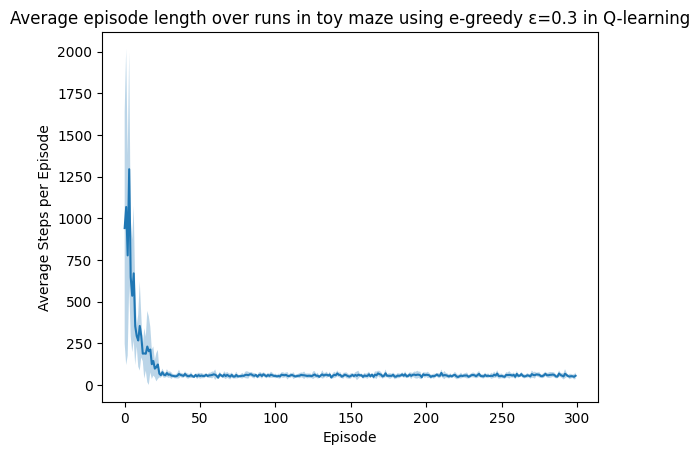

168 steps at episode 1
1204 steps at episode 2
1366 steps at episode 3
846 steps at episode 4
362 steps at episode 5
148 steps at episode 6
446 steps at episode 7
144 steps at episode 8
192 steps at episode 9
302 steps at episode 10
276 steps at episode 11
348 steps at episode 12
332 steps at episode 13
138 steps at episode 14
266 steps at episode 15
554 steps at episode 16
1090 steps at episode 17
220 steps at episode 18
198 steps at episode 19
354 steps at episode 20
272 steps at episode 21
284 steps at episode 22
150 steps at episode 23
502 steps at episode 24
250 steps at episode 25
80 steps at episode 26
800 steps at episode 27
314 steps at episode 28
70 steps at episode 29
282 steps at episode 30
228 steps at episode 31
178 steps at episode 32
380 steps at episode 33
310 steps at episode 34
422 steps at episode 35
318 steps at episode 36
120 steps at episode 37
200 steps at episode 38
594 steps at episode 39
556 steps at episode 40
200 steps at episode 41
170 steps at episode 42


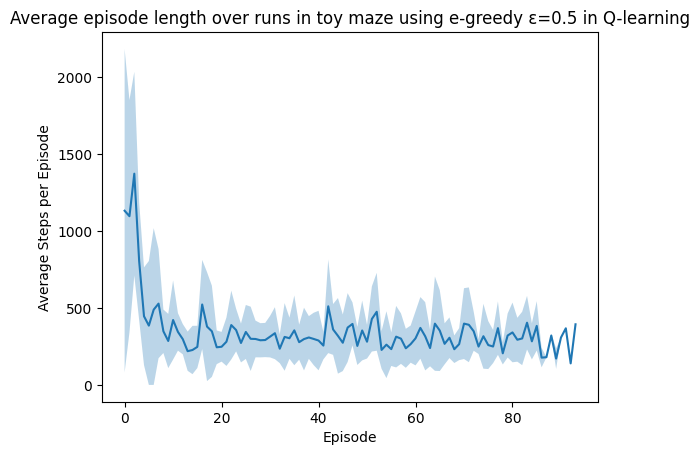

2548 steps at episode 1
27452 steps at episode 2
30000 steps reached. Terminating current episode.
Stopped at episode number: 2
1536 steps at episode 1
28464 steps at episode 2
30000 steps reached. Terminating current episode.
Stopped at episode number: 2
1990 steps at episode 1
28010 steps at episode 2
30000 steps reached. Terminating current episode.
Stopped at episode number: 2
208 steps at episode 1
29792 steps at episode 2
30000 steps reached. Terminating current episode.
Stopped at episode number: 2
1776 steps at episode 1
28224 steps at episode 2
30000 steps reached. Terminating current episode.
Stopped at episode number: 2
802 steps at episode 1
29198 steps at episode 2
30000 steps reached. Terminating current episode.
Stopped at episode number: 2
1880 steps at episode 1
28120 steps at episode 2
30000 steps reached. Terminating current episode.
Stopped at episode number: 2
246 steps at episode 1
29754 steps at episode 2
30000 steps reached. Terminating current episode.
Stopped 

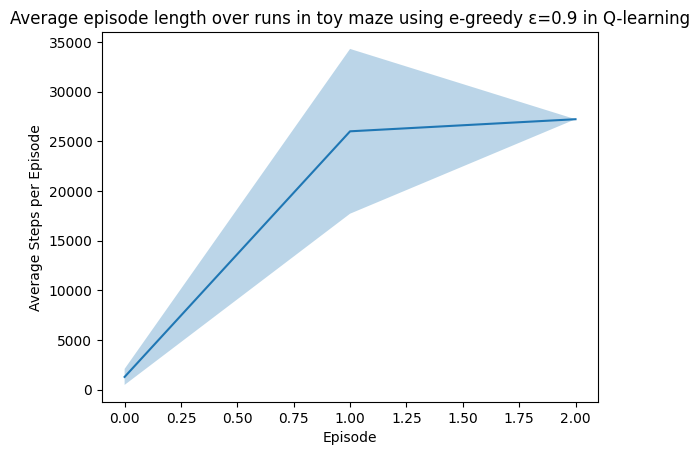

In [135]:
epsilons = [0, 0.1, 0.3, 0.5, 0.9]

for eps in epsilons:
    plot_average_episode_lengths(run_multiple_q(toy_maze, early_stop=30000, strategy="e_greedy", eps=eps), "toy", learning_type=f"e-greedy ε={eps} in Q-learning")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 9

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10

900 steps at episode 1
248 steps at episode 2
364 steps at episode 3
424 steps at episode 4
446 steps at episode 5
424 steps at episode 6
394 steps at episode 7
422 steps at episode 8
498 steps at episode 9
72 steps at episode 10
1076 steps at episode 11
304 steps at episode 12
128 steps at episode 13
76 steps at episode 14
190 steps at episode 15
164 steps at episode 16
380 steps at episode 17
296 steps at episode 18
310 steps at episode 19
62 steps at episode 20
72 steps at episode 21
134 steps at episode 22
26 steps at episode 23
56 steps at episode 24
38 steps at episode 25
182 steps at episode 26
214 steps at episode 27
28 steps at episode 28
42 steps at episode 29
26 steps at episode 30
24 steps at episode 31
48 steps at episode 32
24 steps at episode 33
24 steps at episode 34
24 steps at episode 35
24 steps at episode 36
24 steps at episode 37
24 steps at episode 38
24 steps at episode 39
24 steps at episode 40
24 steps at episode 41
24 steps at episode 42
24 steps at episode 43

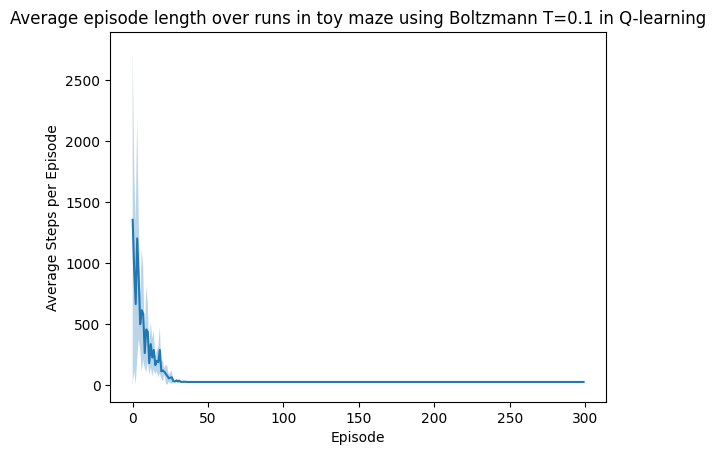

1598 steps at episode 1
832 steps at episode 2
672 steps at episode 3
3930 steps at episode 4
466 steps at episode 5
1150 steps at episode 6
456 steps at episode 7
250 steps at episode 8
52 steps at episode 9
840 steps at episode 10
86 steps at episode 11
86 steps at episode 12
234 steps at episode 13
92 steps at episode 14
154 steps at episode 15
326 steps at episode 16
226 steps at episode 17
524 steps at episode 18
114 steps at episode 19
124 steps at episode 20
198 steps at episode 21
94 steps at episode 22
44 steps at episode 23
94 steps at episode 24
66 steps at episode 25
42 steps at episode 26
64 steps at episode 27
28 steps at episode 28
56 steps at episode 29
28 steps at episode 30
30 steps at episode 31
36 steps at episode 32
24 steps at episode 33
32 steps at episode 34
30 steps at episode 35
38 steps at episode 36
30 steps at episode 37
26 steps at episode 38
34 steps at episode 39
32 steps at episode 40
24 steps at episode 41
28 steps at episode 42
32 steps at episode 43


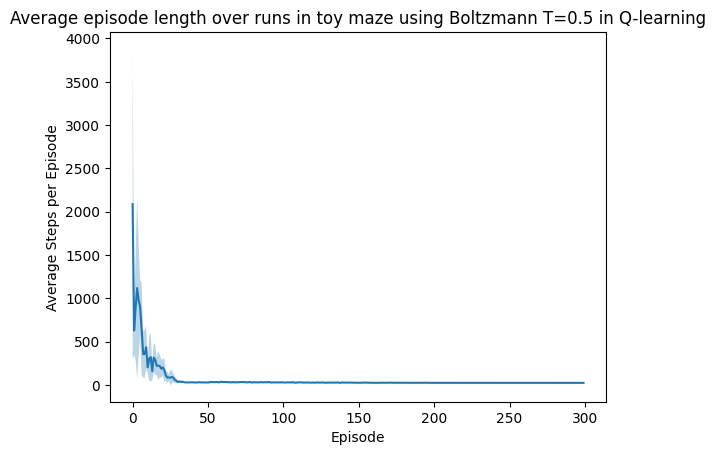

420 steps at episode 1
302 steps at episode 2
158 steps at episode 3
710 steps at episode 4
656 steps at episode 5
1088 steps at episode 6
1078 steps at episode 7
184 steps at episode 8
236 steps at episode 9
308 steps at episode 10
48 steps at episode 11
266 steps at episode 12
164 steps at episode 13
74 steps at episode 14
386 steps at episode 15
200 steps at episode 16
200 steps at episode 17
86 steps at episode 18
170 steps at episode 19
110 steps at episode 20
64 steps at episode 21
226 steps at episode 22
30 steps at episode 23
34 steps at episode 24
58 steps at episode 25
134 steps at episode 26
72 steps at episode 27
44 steps at episode 28
82 steps at episode 29
100 steps at episode 30
74 steps at episode 31
78 steps at episode 32
54 steps at episode 33
40 steps at episode 34
94 steps at episode 35
164 steps at episode 36
54 steps at episode 37
40 steps at episode 38
88 steps at episode 39
80 steps at episode 40
64 steps at episode 41
216 steps at episode 42
54 steps at episode

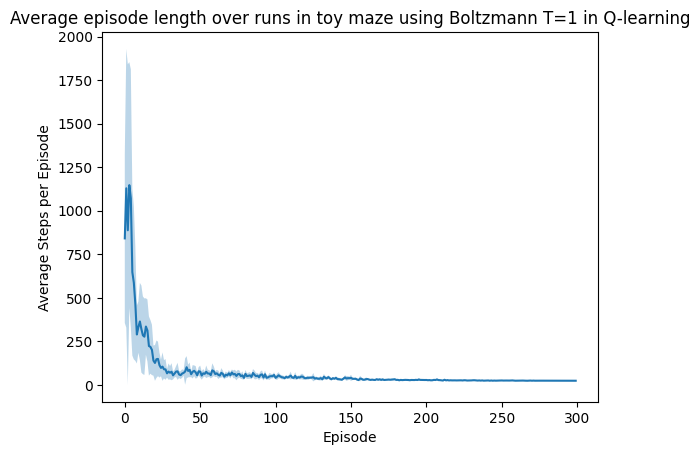

692 steps at episode 1
128 steps at episode 2
126 steps at episode 3
1016 steps at episode 4
1048 steps at episode 5
506 steps at episode 6
362 steps at episode 7
682 steps at episode 8
570 steps at episode 9
578 steps at episode 10
394 steps at episode 11
190 steps at episode 12
658 steps at episode 13
74 steps at episode 14
230 steps at episode 15
192 steps at episode 16
348 steps at episode 17
100 steps at episode 18
166 steps at episode 19
386 steps at episode 20
124 steps at episode 21
224 steps at episode 22
1406 steps at episode 23
238 steps at episode 24
596 steps at episode 25
396 steps at episode 26
674 steps at episode 27
202 steps at episode 28
580 steps at episode 29
396 steps at episode 30
434 steps at episode 31
298 steps at episode 32
660 steps at episode 33
100 steps at episode 34
352 steps at episode 35
1112 steps at episode 36
136 steps at episode 37
248 steps at episode 38
588 steps at episode 39
666 steps at episode 40
446 steps at episode 41
156 steps at episode 4

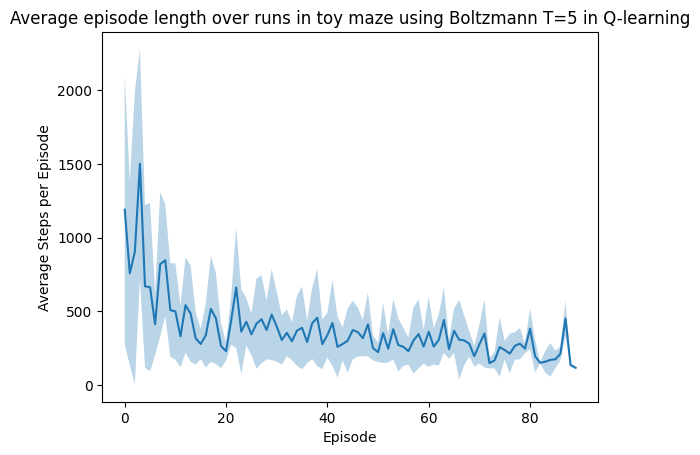

942 steps at episode 1
1046 steps at episode 2
1282 steps at episode 3
1080 steps at episode 4
1876 steps at episode 5
406 steps at episode 6
276 steps at episode 7
2070 steps at episode 8
746 steps at episode 9
574 steps at episode 10
136 steps at episode 11
1840 steps at episode 12
730 steps at episode 13
1478 steps at episode 14
570 steps at episode 15
1300 steps at episode 16
1242 steps at episode 17
2544 steps at episode 18
2934 steps at episode 19
956 steps at episode 20
280 steps at episode 21
786 steps at episode 22
2980 steps at episode 23
300 steps at episode 24
460 steps at episode 25
268 steps at episode 26
832 steps at episode 27
66 steps at episode 28
30000 steps reached. Terminating current episode.
Stopped at episode number: 28
2302 steps at episode 1
468 steps at episode 2
770 steps at episode 3
562 steps at episode 4
192 steps at episode 5
436 steps at episode 6
2554 steps at episode 7
2552 steps at episode 8
2258 steps at episode 9
220 steps at episode 10
860 steps a

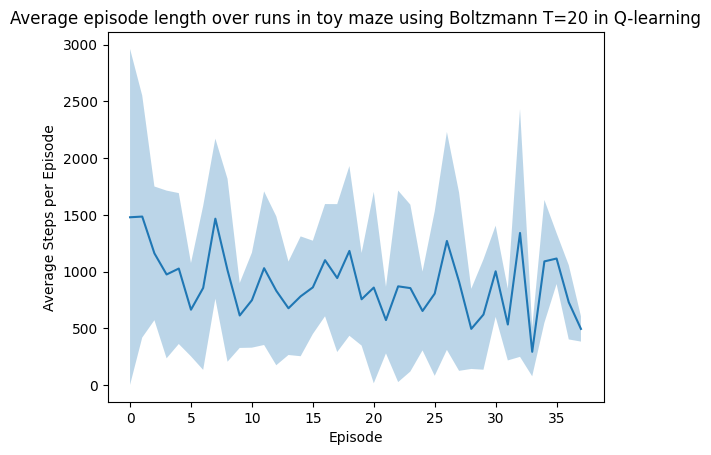

In [136]:
temperatures = [0.1, 0.5, 1, 5, 20]

for t in temperatures:
    plot_average_episode_lengths(run_multiple_q(toy_maze, early_stop=30000, strategy="boltzmann", temperature=t), "toy", learning_type=f"Boltzmann T={t} in Q-learning")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 11

144 steps at episode 1
1438 steps at episode 2
5316 steps at episode 3
3102 steps at episode 4
10000 steps reached. Terminating current episode.
Stopped at episode number: 4
10000 steps at episode 1
10000 steps reached. Terminating current episode.
Stopped at episode number: 1
4342 steps at episode 1
5658 steps at episode 2
10000 steps reached. Terminating current episode.
Stopped at episode number: 2
1880 steps at episode 1
2908 steps at episode 2
1768 steps at episode 3
3444 steps at episode 4
10000 steps reached. Terminating current episode.
Stopped at episode number: 4
736 steps at episode 1
554 steps at episode 2
2192 steps at episode 3
1878 steps at episode 4
402 steps at episode 5
918 steps at episode 6
446 steps at episode 7
172 steps at episode 8
2702 steps at episode 9
10000 steps reached. Terminating current episode.
Stopped at episode number: 9
1368 steps at episode 1
5516 steps at episode 2
2900 steps at episode 3
216 steps at episode 4
10000 steps reached. Terminating cur

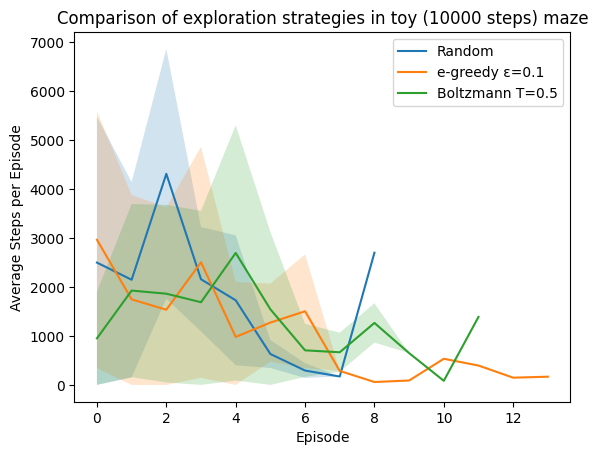

4990 steps at episode 1
2000 steps at episode 2
7080 steps at episode 3
2966 steps at episode 4
6542 steps at episode 5
710 steps at episode 6
512 steps at episode 7
200 steps at episode 8
25000 steps reached. Terminating current episode.
Stopped at episode number: 8
362 steps at episode 1
7702 steps at episode 2
484 steps at episode 3
5810 steps at episode 4
192 steps at episode 5
8196 steps at episode 6
2254 steps at episode 7
25000 steps reached. Terminating current episode.
Stopped at episode number: 7
2746 steps at episode 1
6162 steps at episode 2
2132 steps at episode 3
712 steps at episode 4
4316 steps at episode 5
1278 steps at episode 6
1740 steps at episode 7
852 steps at episode 8
224 steps at episode 9
4838 steps at episode 10
25000 steps reached. Terminating current episode.
Stopped at episode number: 10
260 steps at episode 1
186 steps at episode 2
2430 steps at episode 3
176 steps at episode 4
3624 steps at episode 5
2244 steps at episode 6
2568 steps at episode 7
190 s

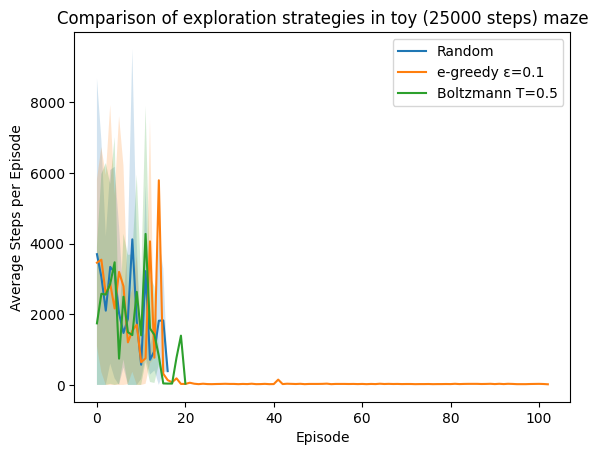

522 steps at episode 1
684 steps at episode 2
2348 steps at episode 3
4512 steps at episode 4
9088 steps at episode 5
17940 steps at episode 6
9162 steps at episode 7
4844 steps at episode 8
3544 steps at episode 9
1832 steps at episode 10
5624 steps at episode 11
498 steps at episode 12
6336 steps at episode 13
12392 steps at episode 14
244 steps at episode 15
396 steps at episode 16
352 steps at episode 17
2958 steps at episode 18
1520 steps at episode 19
4356 steps at episode 20
1628 steps at episode 21
3088 steps at episode 22
234 steps at episode 23
122 steps at episode 24
2696 steps at episode 25
5698 steps at episode 26
328 steps at episode 27
1308 steps at episode 28
14078 steps at episode 29
9434 steps at episode 30
5788 steps at episode 31
686 steps at episode 32
356 steps at episode 33
4690 steps at episode 34
2562 steps at episode 35
1214 steps at episode 36
3422 steps at episode 37
3336 steps at episode 38
6922 steps at episode 39
3044 steps at episode 40
382 steps at epis

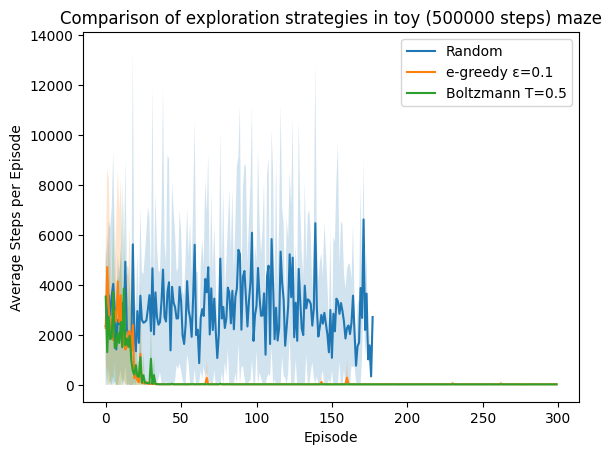

In [140]:
def plot_comparison(all_results_dict, difficulty):
    plt.figure()
    for label, all_runs in all_results_dict.items():
        max_len = max(len(run) for run in all_runs)
        padded = [run + [np.nan] * (max_len - len(run)) for run in all_runs]
        padded = np.array(padded)
        avg = np.nanmean(padded, axis=0)
        std = np.nanstd(padded, axis=0)
        epochs = np.arange(len(avg))
        plt.plot(epochs, avg, label=label)
        plt.fill_between(epochs, np.maximum(avg - std, 0), avg + std, alpha=0.2)
    plt.xlabel("Episode")
    plt.ylabel("Average Steps per Episode")
    plt.title(f"Comparison of exploration strategies in {difficulty} maze")
    plt.legend()
    plt.show()

early_stops = [10000, 25000, 500000]

for stop in early_stops:
    results = {
        "Random": run_multiple_q(easy_maze, strategy="random", early_stop=stop),
        "e-greedy ε=0.1": run_multiple_q(easy_maze, strategy="e_greedy", eps=0.1, early_stop=stop),
        "Boltzmann T=0.5": run_multiple_q(easy_maze, strategy="boltzmann", temperature=0.5, early_stop=stop),
    }
    plot_comparison(results, f"toy ({stop} steps)")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 12

488 steps at episode 1
2818 steps at episode 2
462 steps at episode 3
384 steps at episode 4
252 steps at episode 5
244 steps at episode 6
128 steps at episode 7
766 steps at episode 8
316 steps at episode 9
558 steps at episode 10
164 steps at episode 11
98 steps at episode 12
328 steps at episode 13
176 steps at episode 14
218 steps at episode 15
146 steps at episode 16
288 steps at episode 17
132 steps at episode 18
124 steps at episode 19
150 steps at episode 20
144 steps at episode 21
70 steps at episode 22
44 steps at episode 23
140 steps at episode 24
116 steps at episode 25
50 steps at episode 26
62 steps at episode 27
76 steps at episode 28
50 steps at episode 29
40 steps at episode 30
42 steps at episode 31
64 steps at episode 32
46 steps at episode 33
38 steps at episode 34
46 steps at episode 35
38 steps at episode 36
42 steps at episode 37
52 steps at episode 38
82 steps at episode 39
40 steps at episode 40
64 steps at episode 41
56 steps at episode 42
62 steps at episode 

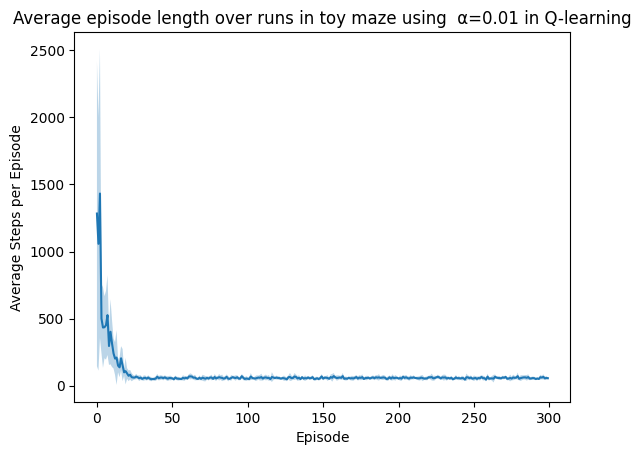

908 steps at episode 1
470 steps at episode 2
1054 steps at episode 3
176 steps at episode 4
710 steps at episode 5
1244 steps at episode 6
492 steps at episode 7
502 steps at episode 8
454 steps at episode 9
82 steps at episode 10
408 steps at episode 11
718 steps at episode 12
294 steps at episode 13
216 steps at episode 14
56 steps at episode 15
106 steps at episode 16
382 steps at episode 17
100 steps at episode 18
448 steps at episode 19
196 steps at episode 20
50 steps at episode 21
90 steps at episode 22
46 steps at episode 23
72 steps at episode 24
44 steps at episode 25
90 steps at episode 26
32 steps at episode 27
60 steps at episode 28
48 steps at episode 29
60 steps at episode 30
46 steps at episode 31
80 steps at episode 32
50 steps at episode 33
46 steps at episode 34
92 steps at episode 35
44 steps at episode 36
74 steps at episode 37
44 steps at episode 38
80 steps at episode 39
34 steps at episode 40
116 steps at episode 41
50 steps at episode 42
70 steps at episode 43

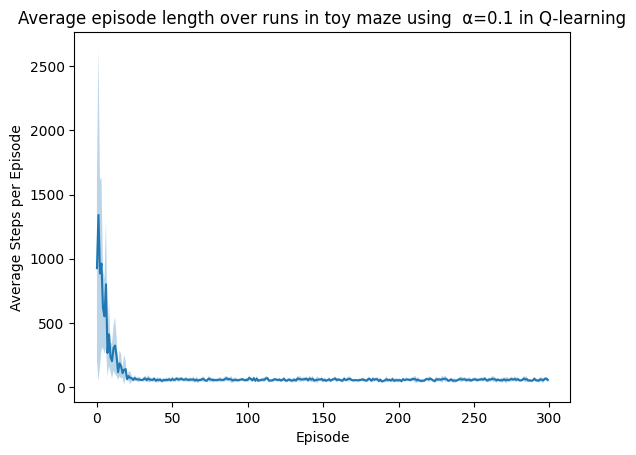

1392 steps at episode 1
1472 steps at episode 2
864 steps at episode 3
194 steps at episode 4
1502 steps at episode 5
308 steps at episode 6
186 steps at episode 7
166 steps at episode 8
314 steps at episode 9
262 steps at episode 10
82 steps at episode 11
296 steps at episode 12
132 steps at episode 13
366 steps at episode 14
230 steps at episode 15
644 steps at episode 16
308 steps at episode 17
78 steps at episode 18
170 steps at episode 19
36 steps at episode 20
80 steps at episode 21
40 steps at episode 22
68 steps at episode 23
60 steps at episode 24
58 steps at episode 25
78 steps at episode 26
54 steps at episode 27
84 steps at episode 28
58 steps at episode 29
66 steps at episode 30
84 steps at episode 31
88 steps at episode 32
72 steps at episode 33
100 steps at episode 34
76 steps at episode 35
82 steps at episode 36
96 steps at episode 37
66 steps at episode 38
40 steps at episode 39
68 steps at episode 40
78 steps at episode 41
38 steps at episode 42
88 steps at episode 43

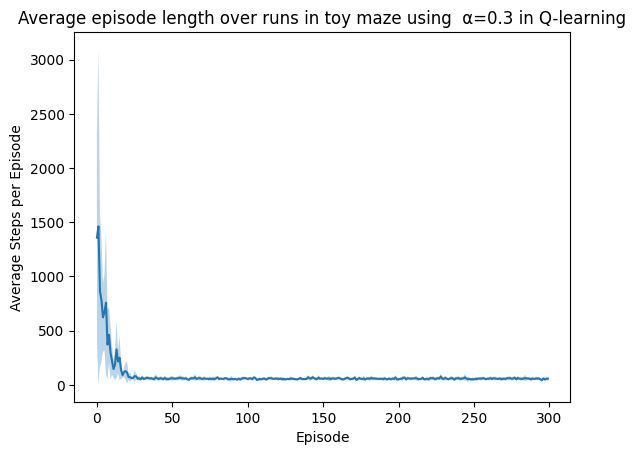

574 steps at episode 1
1226 steps at episode 2
1574 steps at episode 3
962 steps at episode 4
856 steps at episode 5
502 steps at episode 6
212 steps at episode 7
620 steps at episode 8
406 steps at episode 9
240 steps at episode 10
168 steps at episode 11
126 steps at episode 12
212 steps at episode 13
128 steps at episode 14
240 steps at episode 15
204 steps at episode 16
30 steps at episode 17
342 steps at episode 18
38 steps at episode 19
98 steps at episode 20
92 steps at episode 21
52 steps at episode 22
96 steps at episode 23
52 steps at episode 24
76 steps at episode 25
66 steps at episode 26
46 steps at episode 27
34 steps at episode 28
124 steps at episode 29
42 steps at episode 30
64 steps at episode 31
68 steps at episode 32
56 steps at episode 33
48 steps at episode 34
54 steps at episode 35
54 steps at episode 36
84 steps at episode 37
44 steps at episode 38
44 steps at episode 39
32 steps at episode 40
98 steps at episode 41
54 steps at episode 42
32 steps at episode 43


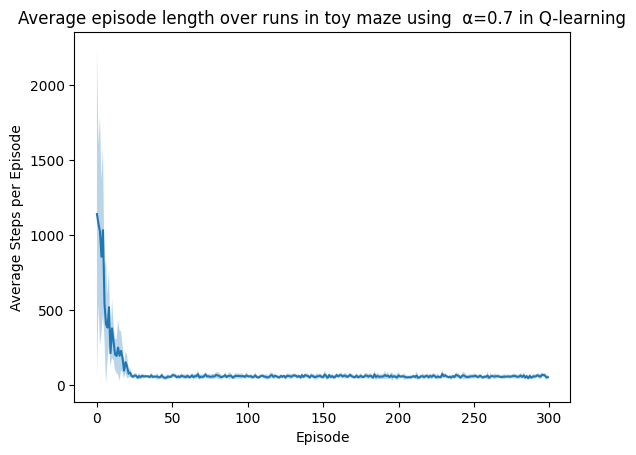

2506 steps at episode 1
282 steps at episode 2
614 steps at episode 3
286 steps at episode 4
330 steps at episode 5
638 steps at episode 6
452 steps at episode 7
398 steps at episode 8
464 steps at episode 9
144 steps at episode 10
224 steps at episode 11
196 steps at episode 12
120 steps at episode 13
118 steps at episode 14
262 steps at episode 15
128 steps at episode 16
166 steps at episode 17
618 steps at episode 18
316 steps at episode 19
50 steps at episode 20
310 steps at episode 21
44 steps at episode 22
120 steps at episode 23
134 steps at episode 24
88 steps at episode 25
70 steps at episode 26
46 steps at episode 27
54 steps at episode 28
44 steps at episode 29
100 steps at episode 30
74 steps at episode 31
58 steps at episode 32
52 steps at episode 33
56 steps at episode 34
52 steps at episode 35
68 steps at episode 36
60 steps at episode 37
64 steps at episode 38
42 steps at episode 39
52 steps at episode 40
54 steps at episode 41
40 steps at episode 42
56 steps at episode

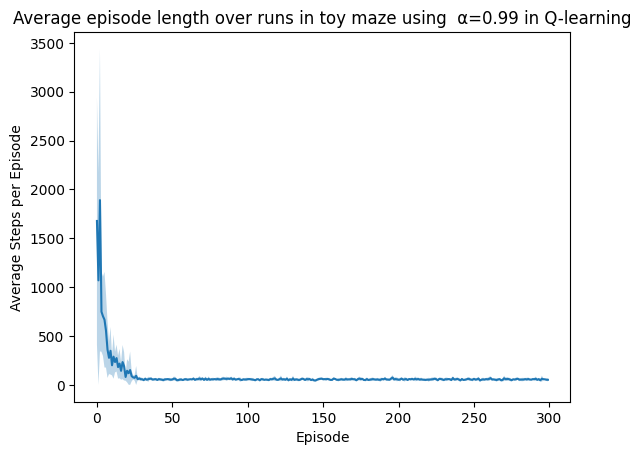

In [141]:
alpha = [0.01, 0.1, 0.3, 0.7, 0.99]

for a in alpha:
    plot_average_episode_lengths(run_multiple_q(toy_maze, early_stop = 30000, strategy="e_greedy", eps=0.3, params={"lr": a, "gamma": 0.9}), "toy", learning_type=f" α={a} in Q-learning")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.3 Introducing More Rewards
#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper
#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**